
---

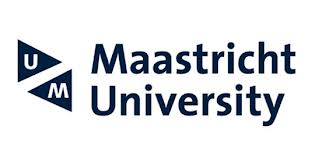

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours




# Faculty of Science and Engineering - Department of Advanced Computer Sciences Course Advanced Natural Language Processing (ANLP) - Tutorial Statistical Approaches to NLP

⏱️ **Estimated time:** 2.3 hours – 5.0 hours


By Jan Scholtes

Version 2026-2027

Welcome to the tutorial on statistical methods in NLP. In this notebook you will learn how we can overcome some of the limitations of traditional, grammar-based approaches (dealing with ambiguity, but also with wrong spelling or wrong grammatical use of words and other unexpected situations).

This will help you understand why statistical and deep-learning methods are so much better for many of the NLP tasks we discuss in this course.

In this notebook, we will use the Stanford NLTK library.

## Learning Goals

After completing this tutorial, you will be able to:

- **Understand** which, when and how statistical preprocessing methods can improve text-mining quality.
- **Understand** Naive Bayes, Hidden Markov Models (HMM), Maximum Entropy Markov Models (MEMM) and Conditional Random Fields (CRF) in more detail so you can apply them successfully for NLP tasks.
- **Explain** the progression from bag-of-words models (Naive Bayes) through sequence models (HMM, MEMM, CRF) and why each step was necessary.
- **Apply** HMM and CRF models for POS tagging and compare their strengths and limitations.
- **Discuss** why CRFs remain relevant even in the age of large language models.

## Language as a Sequence Model

In the previous tutorial, we explored grammar-based approaches to NLP: Finite State Grammars, Context-Free Grammars (CFG), and Probabilistic CFGs (PCFG). These approaches treat language through explicit syntactic rules.

But there is another way to think about language: **as a sequence problem**.

> *"There is no grammar. There are only sequences of words."*

**Autoregressive modeling** asks: *"Given the previous sequence of words, what comes next?"* This is the fundamental question behind statistical language models. Not only next-word prediction, but also POS-tagging, Named Entity Recognition, and other tagging and classification tasks in NLP.

### Why does this work?

Natural language is **temporal** by nature:
- It requires **temporal reasoning**
- It is both **left** and **right** context-sensitive
- It has **long distance** (inter-sentential) relations

We need statistics that can deal with sequences and predict correctly over long distances.

### Statistical Models for Sequences

| Model | Type | Key Property |
|-------|------|-------------|
| **Naive Bayes** | Generative, no sequence | Assumes feature independence |
| **HMM** | Generative, sequence | Markov assumption + hidden states |
| **MEMM** | Discriminative, sequence | Feature functions + local normalization |
| **CRF** | Discriminative, sequence | Feature functions + global normalization |

Naive Bayes works for bag-of-words tasks (spam detection, topic classification) but not for structured problems like tagging or segmentation -- because words in a sentence are *not* independent, and NB has no notion of sequence. This is why we need **Markov Models**: they are a special (simplified) case of Bayesian Networks that can efficiently handle sequential dependencies.

In this tutorial, we focus on **HMM** and **CRF**, the two most important statistical models for NLP sequence tasks.

Hidden Markov Models (HMMs) largely used to assign the correct label sequence
to sequential data or assess the probability of a given label and data
sequence. These models are finite state machines characterised by a number of
states, transitions between these states, and output symbols emitted while in
each state. The HMM is an extension to the Markov chain, where each state
corresponds deterministically to a given event. In the HMM the observation is
a probabilistic function of the state. HMMs share the Markov chain's
assumption, being that the probability of transition from one state to another
only depends on the current state - i.e. the series of states that led to the
current state are not used. They are also time invariant.

The HMM is a directed graph, with probability weighted edges (representing the
probability of a transition between the source and sink states) where each
vertex emits an output symbol when entered. The symbol (or observation) is
non-deterministically generated. For this reason, knowing that a sequence of
output observations was generated by a given HMM does not mean that the
corresponding sequence of states (and what the current state is) is known.
This is the 'hidden' in the hidden markov model.

Formally, a HMM can be characterised by:

- the output observation alphabet. This is the set of symbols which may be
  observed as output of the system.
- the set of states.
- the transition probabilities *a_{ij} = P(s_t = j | s_{t-1} = i)*. These
  represent the probability of transition to each state from a given state.
- the output probability matrix *b_i(k) = P(X_t = o_k | s_t = i)*. These
  represent the probability of observing each symbol in a given state.
- the initial state distribution. This gives the probability of starting
  in each state.

To ground this discussion, take a common NLP application, part-of-speech (POS)
tagging. An HMM is desirable for this task as the highest probability tag
sequence can be calculated for a given sequence of word forms. This differs
from other tagging techniques which often tag each word individually, seeking
to optimise each individual tagging greedily without regard to the optimal
combination of tags for a larger unit, such as a sentence. The HMM does this
with the Viterbi algorithm, which efficiently computes the optimal path
through the graph given the sequence of words forms.

In POS tagging the states usually have a 1:1 correspondence with the tag
alphabet - i.e. each state represents a single tag. The output observation
alphabet is the set of word forms (the lexicon), and the remaining three
parameters are derived by a training regime. With this information the
probability of a given sentence can be easily derived, by simply summing the
probability of each distinct path through the model. Similarly, the highest
probability tagging sequence can be derived with the Viterbi algorithm,
yielding a state sequence which can be mapped into a tag sequence.

This discussion assumes that the HMM has been trained. This is probably the
most difficult task with the model, and requires either Maximum Likelihood Estimation (MLE) estimates of the
parameters or unsupervised learning using the Baum-Welch algorithm, a variant
of Entropy Modeling (EM).

Let's start training a HMM model and takeit from there...

# Hidden Markov Models



Training a HMM model for POS tagging

First import probability FreqDist

We will use the Penn treebank corpus in the NLTK data to train the HMM tagger. To import the treebank use the following code:

In [ ]:
# Install required packages (skips already-installed ones)
import subprocess, sys, importlib

packages = {
    "python-crfsuite": "pycrfsuite",
    "sklearn-crfsuite": "sklearn_crfsuite",
}

to_install = [pip_name for pip_name, import_name in packages.items()
               if importlib.util.find_spec(import_name) is None]

if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])
    print(f"Installed: {', '.join(to_install)}")
else:
    print("All packages already installed \u2014 nothing to do.")


In [ ]:
import nltk
nltk.download('treebank')
from nltk.corpus import treebank

In [ ]:
from nltk.probability import FreqDist

Let's take a look at the distribution of tags in the corpus

In [ ]:
fd = FreqDist()
for word, tag in treebank.tagged_words():
    fd[tag] += 1
fd.items()

We need to import the HMM module as well, using the following code:

In [ ]:
from nltk.tag import hmm

We can instantiate a HMM-Trainer object and assign it to a trainer variable using:

In [ ]:
trainer = hmm.HiddenMarkovModelTrainer()

We can investigate the tagged words in the corpus:

In [ ]:
treebank.tagged_words()[:10]

The following function returns the first two tagged sentences from the corpus:

In [ ]:
treebank.tagged_sents()[:2]


In [ ]:
print("Total tagged sentences: ")
print(len(treebank.tagged_sents()))

Supervised training maximising the joint probability of the symbol and
state sequences. This is done via collecting frequencies of
transitions between states, symbol observations while within each
state and which states start a sentence. These frequency distributions
are then normalised into probability estimates, which can be
smoothed if desired.

It is also possible to train the HMM unsupervised. We will get back to that later in the Entropy Modeling section.

The NLTK HMM-module offers supervised and unsupervised training methods. Here we train an HMM using a supervised (or Maximum Likelihood Estimate) method:

In [ ]:
tagger = trainer.train_supervised(treebank.tagged_sents())

What is in the tagger?

In [ ]:
tagger

Using a HMM model for POS tagging. First load a tokenizer from NLTK

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import word_tokenize

In [ ]:
word_tokenize("Today is a good day.")

Next, load the tokenized structure into the HMM tagger

In [ ]:
tagger.tag(word_tokenize("Today is a good day. Yesterday was also a great day"))

Let's take a look at the probability of this sequence.

In [ ]:
tagger.probability(tagger.tag(word_tokenize("Today is a good day. Yesterday was also a great day")))

As we discussed, probabilities can become very small, resulting in a floating point under flow. This is why we aften use log probability.

In [ ]:
tagger.log_probability(tagger.tag(word_tokenize("Today is a good day. Yesterday was also a great day")))

In [ ]:
tagger.tag(word_tokenize("Jan Scholtes is a name that does not occur in the corpus. What do you observe? Can you explain?"))

In [ ]:
tagger.probability(tagger.tag(word_tokenize("Jan Scholtes is a name that does not occur in the corpus. What do you observe? Can you explain?")))

In [ ]:
tagger.log_probability(tagger.tag(word_tokenize("Jan Scholtes is a name that does not occur in the corpus. What do you observe? Can you explain?")))

To print the names of the 46 hidden states and the 12408 output symbols (observations) to understand what the model is capable of can be printed using the following code:

In [ ]:
# Word Sequence Probabilities (c)
seq = word_tokenize("Yesterday was a good day.")
word_sequence = tagger.tag(seq)

# Untagged sentence
print("Tagged sentence:", word_sequence)

print("Word sequence probability", tagger.probability(word_sequence))
print("Word sequence log-probability", tagger.log_probability(word_sequence))
print()

# Tag Sequence Probabilities (c)

# It seems there is no direct way to compute the tag sequence probability?
# The probability and log_probability methods compute the probability of a tagged sequence.
# The following lines will now calculate the probability of the tags assigned by the tagger.
tags = tagger.tag(word_tokenize("Today is a good day. Yesterday was also a great day")) # Example tag sequence from previous cell

print("Tag sequence:", tags)
print(tagger._transitions)

print("Tag sequence probability", tagger.probability(tags))
print("Tag sequence log-probability", tagger.log_probability(tags))
print()


# Evaluate the quality on train data, since there is no test set here (d)

print("Accuracy:", tagger.accuracy(treebank.tagged_sents()))
print()

# Print states and symbols (e)
print("States")
print(tagger._states)
print("Symbols")
print(tagger._symbols)

In [ ]:
# Print states and symbols for the sentence "Yesterday was a good day."
seq = word_tokenize("Yesterday was a good day.")
tagged_seq = tagger.tag(seq)

print("States and Symbols for 'Yesterday was a good day.':")
for word, tag in tagged_seq:
    print(f"Word: {word}, Tag: {tag}")

# Conditional Random Fields

In [ ]:
# Import the toolkit and tags
from nltk.corpus import treebank

In [ ]:
# Import CRF module

import pycrfsuite
from nltk.tag import CRFTagger




In [ ]:
# Train data - pretagged
train_data = treebank.tagged_sents()     #<same_as_previous>
train_data[:2]

Let's re-check how many tagged sentences we have in our training data set:

In [ ]:
print("Total tagged sentences: ")
print(len(train_data))


Let's train it! This might take a minute or so:

In [ ]:
# Setup a trainer with default(None) values
# Train with the data
# This will take a few minutes...
taggerCRF = CRFTagger(verbose=True)
taggerCRF.train(train_data, 'model.crf.tagger')

## Exploring CRF Feature Functions

The power of CRFs comes from their **feature functions**. Unlike HMMs, which are limited to transition and emission probabilities, CRFs can use arbitrary features of the input -- including word shape, capitalization, suffixes, and neighboring words.

With the function `taggerCRF._get_features(sentence_tokens)` we can analyze the internal feature functions of the CRF parser. Below we extract these features and list the values for a number of sentences.

In [ ]:
features_list = []
for i in range(5):
    sentence_tokens = [word for word, tag in train_data[i]]
    features = [taggerCRF._get_features(sentence_tokens, idx) for idx in range(len(sentence_tokens))]
    features_list.append((sentence_tokens, features))

for i, (tokens, features) in enumerate(features_list):
    print(f"Features for Sample {i + 1}:")
    for idx, token_features in enumerate(features):
        print(f"Token {tokens[idx]}: {token_features}")
    print("\n")

In [ ]:
features_list_b = []
for i in range(5):
    sentence_tokens = [word for word, tag in train_data[i]]
    features = [taggerCRF._get_features(sentence_tokens, idx) for idx in range(len(sentence_tokens))]
    features_list_b.append((sentence_tokens, features))

for i, (tokens, features) in enumerate(features_list_b):
    print(f"Features for Training Example {i + 1}:")
    for idx, token_features in enumerate(features):
        print(f"Token {tokens[idx]}: {token_features}")
    print("\n")

Or in a slightly different layout

In [ ]:
def word2features(sent, i):
    word = sent[i][0]
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
    }
    if i > 0:
        word1 = sent[i-1][0]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = 1.0 # Beginning Of Sentence

    if i < len(sent)-1:
        word1 = sent[i+1][0]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = 1.0 # End Of Sentence

    return features

# Apply the feature function to the first 5 sentences in the training data
for i in range(5):
    sentence = train_data[i] # train_data already contains tagged words
    print(f"Features for sentence {i+1}:")
    for j in range(len(sentence)):
        features = word2features(sentence, j)
        print(f"  Word '{sentence[j][0]}': {features}")
    print("-" * 20)

Now let's try the same sentences we analyzed with the HMM with a CRF.

In [ ]:
taggerCRF.tag(word_tokenize("Today is a good day. Yesterday was also a great day"))


In [ ]:
taggerCRF.tag(word_tokenize("Jan Scholtes is a name that does not occur in the corpus. What do you observe? Can you explain?"))

Please observe how well the quality of this algorithm already is with a few feature functions! Can you imagine how powerfull this is with 300+ feature functions!

## Conditional Random Fields (CRFs) in NLP

### What tasks are they used for, and why?

### 1. What is a CRF (in one sentence)?

A Conditional Random Field (CRF) is a probabilistic graphical model used to predict sequences of labels for sequences of inputs, modeling dependencies between neighboring output labels.

In NLP, you use a CRF when you need *structured prediction*, not just independent classification of each token.

---

## Why classification alone is not enough:

Many NLP tasks require predicting a label sequence (e.g., B-PER, I-PER, O...), where labels have dependencies.
Example: In Named Entity Recognition (NER), the label `I-ORG` (inside an organization name) should not follow `B-PER` (beginning of a person name). A standard classifier (like logistic regression or a per-token softmax) treats each token independently and cannot enforce structural constraints.

CRFs solve this: they model the *joint probability of all labels conditioned on the input sequence*, allowing us to incorporate:

* Transition probabilities (label-to-label dependencies)
* Rich features (word morphology, POS tags, capitalization, embeddings, etc.)

## NLP tasks where CRFs excel

###  **1. Named Entity Recognition (NER)**

Extracting entities from text (e.g., people, organizations, locations).

* Input: `Barack Obama visited Paris .`
* Output: `B-PER I-PER O B-LOC O`

Why CRF is useful:

* Enforces valid sequences (no `I-PER` after `O`)
* Learns common label transitions (B-PER → I-PER is common)

---

###  **2. Part-of-Speech (POS) Tagging**

Assigning syntactic roles (NOUN, VERB, ADJ, ...).

Example dependency:

* Determiners ("the", "a") are frequently followed by nouns.

CRFs model these transitions effectively.

---

###  **3. Chunking / Shallow Parsing**

Identify syntactic spans like noun phrases or verb phrases.

Example:

```
[NP The quick brown fox ] [VP jumps ] [PP over ] [NP the lazy dog ]
```

BIO or BILOU tagging formats are sequence labeling formats that CRFs were designed to optimize.

---

###  **4. Under-resourced or feature-rich tasks**

CRFs allow integration of hand-defined features, useful for:

* Token shape (`Xxxx`, `xxx`, `XXX`)
* Prefixes/suffixes (useful for morphology)
* Gazetteers (lists of known names/terms)

Tasks where this matters:

| Task                                            | Why CRF helps                                               |
| ----------------------------------------------- | ----------------------------------------------------------- |
| Medical / Legal entity extraction          | Uses domain-specific dictionaries + CRF transitions         |
| Extracting slots from user utterances (NLU) | Slot values are sequential and interdependent               |
| OCR post-processing / error correction   | Sequential constraints help improve noisy token predictions |

---

###  **5. Sequence labeling in hybrid neural architectures**

CRFs are often combined with neural encoders:

* BiLSTM + CRF
* Transformer + CRF

The neural encoder produces token representations, while the CRF ensures*valid label sequences.

> Softmax gives best *per-token* classification.
> CRFs give best *sequence-consistent* classification.

This combination is still state-of-the-art in low-resource settings or when structured predictions matter.

---

## When not to use CRFs

* For tasks where the output is not a sequence (e.g., text classification).
* When dependencies are long-range across sentences (CRF mainly models local transitions).
* When large pretrained LLMs handle the structure implicitly.

---

Use a CRF whenever you want to assign a label to each token, and the correctness of one label depends on its neighbors.

Especially for:

* Named entity recognition
* POS tagging
* Chunking
* Slot filling
* Sequence labeling tasks using BIO/BILOU schemes



## Why Conditional Random Fields (CRFs) are still relevant

### (even though LLMs are more powerful and can learn contextual structure automatically)

Large Language Models (LLMs) like GPT-5, GPT-4, or fine-tuned BERT-style models are excellent sequence labelers. They automatically learn contextual dependencies and rarely require manual feature engineering. However, CRFs continue to be used in real-world production systems, especially where:

* Training data is limited
* Models must run on resource-constrained devices
* Predictions must obey strict structural or domain constraints
* Interpretability and reproducibility matter

---

## 1. CRFs are data-efficient

LLMs need large amounts of labeled data to perform well on specialized sequence labeling tasks (e.g., medical NER, legal citation extraction, domain-specific slot tagging).

CRFs, by contrast:

* Can perform well with small labeled datasets (hundreds or low thousands of examples).
* Allow feature engineering, so experts can inject domain knowledge explicitly (gazetteers, token shape, regex, morphological features).

Example:

| Model type         | NER dataset size needed for good performance |
| ------------------ | -------------------------------------------- |
| LLM (fine-tune)    | tens of thousands to millions of tokens      |
| CRF (feature-rich) | a few hundred annotated sentences            |

This makes CRFs ideal for:

* Low-resource languages
* Domain-specific corpus (legal, medical, financial)
* Situations where annotation is expensive or slow

---

## 2. CRFs are computationally lightweight

CRFs require:

* Minimal RAM (MBs instead of GBs)
* No GPU for inference or training
* Low latency (useful in embedded / on-device NLP)

LLMs require:

* Large VRAM / cloud compute access
* High runtime energy usage
* Continuous internet access if using API-based inference

On devices like medical devices, watches, microcontrollers, edge devices, CRFs are often the only feasible choice.

> CRF inference time grows linearly with sequence length.
> LLM inference time grows with sequence length × model depth × attention cost.

---

## 3. CRFs provide structured control over the output

CRFs explicitly model label-to-label dependencies.

A CRF can enforce rules such as:

* `I-ORG` cannot appear without a preceding `B-ORG`
* A date must follow a trigger token "on" or "at"
* Slot labels form valid sequences (BIO/BILOU consistency)

LLMs *tend* to follow these patterns but do not guarantee them.

Example failure from LLM (token tagging):

```
B-PER  I-PER  O  I-PER  <- invalid transition
```

Example from CRF:

```
B-PER  I-PER  O  B-PER  <- valid, constraints applied
```

For safety-critical applications (clinical NER, legal contract extraction), deterministic behavior matters.

---

## 4. CRFs are interpretable and auditable

CRFs provide:

* Feature weight vectors (clear importance scores)
* Explicit modeling assumptions
* Transparent decision functions

LLMs do not.

For regulated domains (finance, healthcare, law), CRFs are often preferred because:

> “Why did the model extract this entity?”
> —can be answered with a CRF.
> —cannot be clearly answered with an LLM.

---


## Final explanation

CRFs remain useful because they are **data-efficient, computationally efficient, and structurally constrained** sequence labeling models. Unlike LLMs, CRFs do not require large annotated datasets or GPUs and can run on low-power devices with very low latency. They allow explicit incorporation of domain knowledge and enforce valid label transitions, producing deterministic and interpretable output. Although LLMs are superior for complex contextual reasoning, CRFs are still the preferred choice in **low-resource, low-power, or high-regulation environments**.



## Conceptual Reflection Questions

*Practice explaining these concepts as if on a pen-and-paper exam:*

1. **Label bias problem**: Explain the label bias problem in MEMMs. Why doesn't CRF suffer from it? (Hint: local vs global normalization)

2. **CRF vs HMM for sparse data**: Why can CRFs handle sparse training data and OOV words better than HMMs? (Hint: think about feature functions vs probability tables)

3. **Generative vs Discriminative**: HMMs model P(observations, states) jointly. CRFs model P(states | observations) directly. What practical advantage does the discriminative approach give?

4. **When HMMs fail**: "CRFs cannot deal with out-of-vocabulary words" — is this True or False? Explain why.

## Take Away: Overview of NLP Methods

We have now covered the major approaches to Natural Language Processing across three paradigms:

### Linguistic Approaches
- **Morphology**: Lexicons, inflection and stemming rules
- **Syntax**: Finite State Grammar (FSG) -> Context-Free Grammar (CFG) -> Probabilistic CFG (PCFG)
- **Semantics**: Dependency Grammar for forwards and backwards semantic relations

### Statistical Approaches (this tutorial)
- **HMM**: Generative model with Markov assumption; Viterbi algorithm for decoding
- **MEMM**: Discriminative model with feature functions; suffers from label bias
- **CRF**: Discriminative model with global normalization; fixes label bias problem

### Deep Learning Approaches (next tutorials)
- **LSTM**: Looks at past words (Word2Vec, GloVe embeddings)
- **Bi-directional LSTM**: Looks at past and future words (ELMo)
- **Transformers and BERT**: Multi-headed self-attention over entire sequences

### The Progression

Each step addresses a limitation of the previous approach:

1. **Naive Bayes** assumes feature independence -- but words in language are *not* independent
2. **HMM** adds sequential dependencies -- but only looks backwards and has limited features
3. **MEMM** adds arbitrary feature functions -- but suffers from label bias (local normalization)
4. **CRF** fixes label bias with global normalization -- but still requires manual feature engineering
5. **Deep Learning** learns features automatically from data -- the topic of our next tutorials

> In the next tutorial, we will take the step to deep learning models and see how they overcome the limitations of CRFs.

# Exercises

## Exercise A0: Viterbi Algorithm By Hand (15 points)

*This pen-and-paper exercise prepares you for exam questions about HMM/Viterbi.*

Consider a simple HMM for POS tagging with:

**States (tags):** NOUN (N), VERB (V), DET (D)

**Start probabilities:**
| State | P(start) |
|---|---|
| N | 0.1 |
| V | 0.1 |
| D | 0.8 |

**Transition probabilities:**
| From \ To | N | V | D |
|---|---|---|---|
| N | 0.2 | 0.6 | 0.2 |
| V | 0.5 | 0.1 | 0.4 |
| D | 0.8 | 0.1 | 0.1 |

**Emission probabilities:**
| State | "the" | "dog" | "runs" | "fast" |
|---|---|---|---|---|
| N | 0.01 | 0.5 | 0.1 | 0.39 |
| V | 0.01 | 0.01 | 0.7 | 0.28 |
| D | 0.9 | 0.01 | 0.01 | 0.08 |

**a)** (10 points) Run the Viterbi algorithm by hand for the sentence **"the dog runs"**. Show the computation for each word:
- For each state at each time step, compute the Viterbi probability and record the backpointer
- Fill in the trellis table below and report the most likely tag sequence

| Time step | Word | State N | State V | State D | 
|---|---|---|---|---|
| t=1 | "the" | P = ?, bp = - | P = ?, bp = - | P = ?, bp = - |
| t=2 | "dog" | P = ?, bp = ? | P = ?, bp = ? | P = ?, bp = ? |
| t=3 | "runs" | P = ?, bp = ? | P = ?, bp = ? | P = ?, bp = ? |

**b)** (5 points) What would happen if the word "fast" appeared instead of "runs" at t=3? Would the tag sequence change? Explain why the transition probabilities matter here, not just the emission probabilities.

### BEGIN SOLUTION

**a) Viterbi computation for "the dog runs":**

**t=1: "the"**
- V(N,1) = P(start=N) × P("the"|N) = 0.1 × 0.01 = **0.001**
- V(V,1) = P(start=V) × P("the"|V) = 0.1 × 0.01 = **0.001**
- V(D,1) = P(start=D) × P("the"|D) = 0.8 × 0.9 = **0.720**

**t=2: "dog"**
- V(N,2) = max[V(N,1)×P(N→N), V(V,1)×P(V→N), V(D,1)×P(D→N)] × P("dog"|N)
  = max[0.001×0.2, 0.001×0.5, 0.720×0.8] × 0.5
  = max[0.0002, 0.0005, 0.576] × 0.5
  = 0.576 × 0.5 = **0.288**, bp=D
- V(V,2) = max[0.001×0.6, 0.001×0.1, 0.720×0.1] × P("dog"|V)
  = max[0.0006, 0.0001, 0.072] × 0.01
  = 0.072 × 0.01 = **0.00072**, bp=D
- V(D,2) = max[0.001×0.2, 0.001×0.4, 0.720×0.1] × P("dog"|D)
  = max[0.0002, 0.0004, 0.072] × 0.01
  = 0.072 × 0.01 = **0.00072**, bp=D

**t=3: "runs"**
- V(N,3) = max[0.288×0.2, 0.00072×0.5, 0.00072×0.8] × P("runs"|N)
  = max[0.0576, 0.00036, 0.000576] × 0.1
  = 0.0576 × 0.1 = **0.00576**, bp=N
- V(V,3) = max[0.288×0.6, 0.00072×0.1, 0.00072×0.1] × P("runs"|V)
  = max[0.1728, 0.000072, 0.000072] × 0.7
  = 0.1728 × 0.7 = **0.12096**, bp=N
- V(D,3) = max[0.288×0.2, 0.00072×0.4, 0.00072×0.1] × P("runs"|D)
  = max[0.0576, 0.000288, 0.000072] × 0.01
  = 0.0576 × 0.01 = **0.000576**, bp=N

**Best final state:** V at t=3 (0.12096)
**Backtrace:** V←N←D
**Most likely tag sequence: D N V** ("the"=DET, "dog"=NOUN, "runs"=VERB) ✓

| Time step | Word | State N | State V | State D |
|---|---|---|---|---|
| t=1 | "the" | 0.001, bp=- | 0.001, bp=- | **0.720**, bp=- |
| t=2 | "dog" | **0.288**, bp=D | 0.00072, bp=D | 0.00072, bp=D |
| t=3 | "runs" | 0.00576, bp=N | **0.12096**, bp=N | 0.000576, bp=N |

**b)** If "fast" appeared instead of "runs" at t=3:
- V(N,3) = 0.0576 × P("fast"|N) = 0.0576 × 0.39 = 0.02246
- V(V,3) = 0.1728 × P("fast"|V) = 0.1728 × 0.28 = 0.04838
- The tag sequence would still be **D N V** because even though "fast" has a higher emission probability as a NOUN (0.39) than as a VERB (0.28), the transition probability from N→V (0.6) is much higher than N→N (0.2). The Viterbi path through N at t=2 followed by V at t=3 still wins because the product of transition × emission favors V. This illustrates that Viterbi considers the **joint** probability of the entire sequence, not just local emission probabilities — transition context matters.

### END SOLUTIONYOUR ANSWER HERE


## Exercise A1: Limitations of Hidden Markov Models (15 points)

In the HMM section above, you observed that:
- The probability of a tagged sentence can be extremely small (floating point underflow risk)
- The sentence containing "Jan Scholtes" could not be properly POS-tagged

Answer the following questions:

**a)** Why does the *log probability* not suffer from floating point underflows? Explain the mathematical reason.

**b)** Why can the sentence *"Jan Scholtes is a name that does not occur in the corpus..."* not be POS-tagged by this HMM tagger? What fundamental limitation of HMMs does this illustrate?

**c)** How can we solve this problem? Describe at least two different approaches (one within the HMM framework, one using a different model).

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: CRF Feature Engineering (15 points)

The default NLTK CRF tagger uses a basic set of features. In this exercise, you will **extend the feature set** and measure the impact on tagging accuracy.

**Task**: Write a custom feature extraction function `custom_word2features(sent, i)` that includes at least **3 additional features** beyond what the default tagger uses. Examples of useful features:
- Word length
- Whether the word contains a hyphen
- Prefix features (first 2-3 characters)
- Whether the word contains digits
- Suffix patterns

Then train a new CRF model using `sklearn_crfsuite` with your custom features on the treebank training data, split into train (first 3000 sentences) and test (remaining), and report the accuracy.

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A2 (10 points)
assert callable(custom_word2features), "custom_word2features must be defined"
test_sent = [("The", "DT"), ("cat", "NN"), ("sat", "VBD")]
features = custom_word2features(test_sent, 1)
assert isinstance(features, dict), "custom_word2features must return a dict"
assert 'word.lower()' in features, "Must include word.lower() feature"
assert 'bias' in features, "Must include bias feature"
basic_features = {'bias', 'word.lower()', 'word[-3:]', 'word[-2:]',
                  'word.isupper()', 'word.istitle()', 'word.isdigit()',
                  '-1:word.lower()', '-1:word.istitle()', '-1:word.isupper()',
                  '+1:word.lower()', '+1:word.istitle()', '+1:word.isupper()',
                  'BOS', 'EOS'}
extra_features = set(features.keys()) - basic_features
assert len(extra_features) >= 3, f"Must add at least 3 extra features, found {len(extra_features)}: {extra_features}"
assert accuracy > 0.85, f"CRF accuracy should be > 0.85, got {accuracy:.4f}"
print(f"All tests passed! Accuracy: {accuracy:.4f}, Extra features: {extra_features}")

**Explain your feature choices:**

1. What additional features did you add and why?
2. Did the additional features improve accuracy compared to the basic feature set? Why or why not?
3. Which of your features do you think contributed most to the improvement?

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Comparing Statistical NLP Models (15 points)

In this tutorial, you worked with HMM and CRF models for POS tagging. In the lecture, you also learned about Naive Bayes and Maximum Entropy Markov Models (MEMM).

Answer the following questions:

**a)** The CRF parser successfully tagged "Jan Scholtes" as NNP (proper noun) even though these words never appeared in the training data. The HMM failed completely on the same input. Explain *specifically* which CRF features enabled this generalization and *why* the HMM architecture makes this impossible.

**b)** Explain the **label bias problem** in MEMMs. Give a concrete example of how it could lead to incorrect tagging, and explain how CRFs solve it.

**c)** Despite the superiority of deep learning models (Transformers, BERT), CRFs are still used in production NLP systems. Describe **two specific real-world scenarios** where a CRF would be preferred over a large language model, and justify your answer.

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION